# RadSim example python notebook

In [1]:
import math
import startJVM
import jpype
import jpype.imports
import numpy as np
import matplotlib.pyplot as plt

from gov.llnl.rtk.physics import (
    Nuclides,
    SourceImpl,
    DecayCalculator,
    EmissionCalculator,
    Quantity,
    Units,
    Material,
    KleinNishinaDistribution,
    Elements,
)
from gov.bnl.nndc.ensdf.decay import BNLDecayLibrary
from gov.nist.physics.xray import NISTXrayLibrary
from gov.nist.physics.xcom import XCOMPhotonCrossSectionLibrary
from gov.llnl.rtk.response.deposition import CuboidChordGeometry, DepositionCalculator
from java.nio.file import Paths
from java.util import ArrayList


In [2]:
# Optional plotting style
try:
    plt.style.use("matplotlibrc")
except Exception:
    pass

INCH_TO_CM = 2.54
MAX_ENERGY_KEV = 3000.0
NBINS = 3000

DETECTOR = {
    "name": "NaI 2x4x16 in",
    "dimensions_in": (2.0, 4.0, 16.0),   # length, width, height
    "density_g_cm3": 3.67,
    "composition": [
        ("Na", 1.0),
        ("I", 1.0),
    ],
}

SOURCE = {
    "position_cm": (300.0, 0.0, 0.0),  # source at +x, 3 m away
    "apply_inverse_square": False,
}

DETECTOR["dimensions_cm"] = tuple(d * INCH_TO_CM for d in DETECTOR["dimensions_in"])


In [3]:
def add_delta(spectrum, energy_keV, amplitude):
    energy_keV = float(energy_keV)
    amplitude = float(amplitude)

    if not np.isfinite(energy_keV) or not np.isfinite(amplitude):
        return None
    if amplitude <= 0:
        return None

    idx = int(np.floor(energy_keV))
    if 0 <= idx < len(spectrum):
        spectrum[idx] += amplitude
        return idx
    return None


def build_detector_material(detector_cfg):
    builder = Material.builder()
    builder.density(Quantity.of(float(detector_cfg["density_g_cm3"]), "g/cm^3"))
    for symbol, amount in detector_cfg["composition"]:
        builder.add(Elements.get(symbol), float(amount))
    return builder.build()


def build_detector_geometry(detector_cfg):
    length_cm, width_cm, height_cm = detector_cfg["dimensions_cm"]
    chords = CuboidChordGeometry()
    chords.setDimensions(
        Quantity.of(float(length_cm), "cm"),
        Quantity.of(float(width_cm), "cm"),
        Quantity.of(float(height_cm), "cm"),
    )
    return chords


def get_projected_area_cm2_for_axis_aligned_source(detector_cfg, source_pos_cm):
    x, y, z = source_pos_cm
    length_cm, width_cm, height_cm = detector_cfg["dimensions_cm"]

    ax = abs(float(x))
    ay = abs(float(y))
    az = abs(float(z))

    if ax >= ay and ax >= az:
        return width_cm * height_cm
    elif ay >= ax and ay >= az:
        return length_cm * height_cm
    else:
        return length_cm * width_cm


def geometric_factor(detector_cfg, source_cfg):
    sx, sy, sz = source_cfg["position_cm"]
    r_cm = math.sqrt(sx * sx + sy * sy + sz * sz)
    if r_cm <= 0:
        return 1.0

    area_cm2 = get_projected_area_cm2_for_axis_aligned_source(
        detector_cfg, source_cfg["position_cm"]
    )
    return area_cm2 / (4.0 * math.pi * r_cm * r_cm)


In [4]:
# Build decay library
bnllib = BNLDecayLibrary()
bnllib.setXrayLibrary(NISTXrayLibrary.getInstance())
bnllib.loadFile(Paths.get("../src/gov.bnl.nndc.ensdf/py/BNL2023.txt"))

# Source: pure Cs-137, 100 Bq
cs137 = SourceImpl.fromActivity(Nuclides.get("Cs137"), Quantity.of(100.0, "Bq"))

# Compute transient equilibrium mixture
dc = DecayCalculator()
dc.setDecayLibrary(bnllib)
eq_sources = dc.transientEquilibrium(cs137)

print("Transient equilibrium composition from pure Cs-137:")
for s in eq_sources:
    nuclide = str(s.getNuclide())
    atoms = float(s.getAtoms())
    activity = float(s.getActivity(Units.get("Bq")))
    print(f"{nuclide:>10} | atoms = {atoms:.6e} | activity = {activity:.6e} Bq")

source_list_eq = ArrayList()
for s in eq_sources:
    source_list_eq.add(s)


Transient equilibrium composition from pure Cs-137:
    Ba137m | atoms = 2.091963e+04 | activity = 9.469945e+01 Bq
     Cs137 | atoms = 1.366724e+11 | activity = 1.000000e+02 Bq


In [5]:
# Emission calculation from equilibrium mixture
emcal = EmissionCalculator()
emcal.setDecayLibrary(bnllib)
em_out = emcal.apply(source_list_eq)

beta_E, beta_I = [], []
gamma_E, gamma_I = [], []
xray_E, xray_I = [], []

print("\nEmissions from transient equilibrium mixture:")
for emission in em_out.getBetas():
    e = float(emission.getEnergy().getValue())
    i = float(emission.getIntensity().getValue())
    beta_E.append(e)
    beta_I.append(i)
    print(f"Beta- : E = {e:.6f} keV, I = {i:.6e}")

for emission in em_out.getGammas():
    e = float(emission.getEnergy().getValue())
    i = float(emission.getIntensity().getValue())
    gamma_E.append(e)
    gamma_I.append(i)
    print(f"Gamma : E = {e:.6f} keV, I = {i:.6e}")

for emission in em_out.getXrays():
    e = float(emission.getEnergy().getValue())
    i = float(emission.getIntensity().getValue())
    try:
        name = str(emission.getName())
    except Exception:
        name = "xray"
    xray_E.append(e)
    xray_I.append(i)
    print(f"Xray  : E = {e:.6f} keV, I = {i:.6e}, {name}")

beta_E = np.array(beta_E, dtype=float)
beta_I = np.array(beta_I, dtype=float)
gamma_E = np.array(gamma_E, dtype=float)
gamma_I = np.array(gamma_I, dtype=float)
xray_E = np.array(xray_E, dtype=float)
xray_I = np.array(xray_I, dtype=float)



Emissions from transient equilibrium mixture:
Beta- : E = 514.030000 keV, I = 9.469945e+01
Beta- : E = 892.130000 keV, I = 5.799966e-04
Beta- : E = 1176.000000 keV, I = 5.299969e+00
Gamma : E = 283.500000 keV, I = 5.800000e-04
Gamma : E = 661.657000 keV, I = 8.513481e+01
Xray  : E = 3.954000 keV, I = 3.986174e-03, L3-M1
Xray  : E = 4.331000 keV, I = 3.158050e-03, L2-M1
Xray  : E = 4.451300 keV, I = 1.112524e-02, L3-M4
Xray  : E = 4.466500 keV, I = 9.994541e-02, L3-M5
Xray  : E = 4.828300 keV, I = 1.148098e-01, L2-M4
Xray  : E = 4.852000 keV, I = 2.153915e-02, L1-M2
Xray  : E = 4.926000 keV, I = 3.625861e-02, L1-M3
Xray  : E = 4.993500 keV, I = 7.505898e-04, L3-N1
Xray  : E = 5.154400 keV, I = 2.032675e-02, L3-N4,5
Xray  : E = 5.531400 keV, I = 1.676307e-02, L2-N4
Xray  : E = 5.797000 keV, I = 6.526543e-03, L1-N2
Xray  : E = 5.810400 keV, I = 8.654893e-03, L1-N3
Xray  : E = 31.452000 keV, I = 3.877925e-03, K-L1
Xray  : E = 31.817000 keV, I = 2.054435e+00, K-L2
Xray  : E = 32.194000 keV

In [6]:
# Combine photon lines and filter invalid entries
if len(gamma_E) + len(xray_E) == 0:
    raise RuntimeError("No gamma or X-ray emissions found.")

E_src = np.concatenate([gamma_E, xray_E]) if len(xray_E) > 0 else gamma_E.copy()
I_src = np.concatenate([gamma_I, xray_I]) if len(xray_I) > 0 else gamma_I.copy()

valid_mask = np.isfinite(E_src) & np.isfinite(I_src) & (E_src > 0.0) & (I_src > 0.0)

if not np.all(valid_mask):
    print("\nSkipping invalid photon lines:")
    for e, i in zip(E_src[~valid_mask], I_src[~valid_mask]):
        print(f"  bad line: E={e}, I={i}")

E_src = E_src[valid_mask]
I_src = I_src[valid_mask]


In [7]:
# Detector geometry and material
detector_material = build_detector_material(DETECTOR)
chords = build_detector_geometry(DETECTOR)

calc = DepositionCalculator(
    detector_material,
    chords,
    KleinNishinaDistribution(),
    MAX_ENERGY_KEV,
)

calc.setUnits(Units.get("cm"))
calc.setPhotonCrossSectionLibrary(XCOMPhotonCrossSectionLibrary.getInstance())

sx, sy, sz = SOURCE["position_cm"]
calc.setPosition(
    Quantity.of(float(sx), "cm"),
    Quantity.of(float(sy), "cm"),
    Quantity.of(float(sz), "cm"),
)

geom_factor = geometric_factor(DETECTOR, SOURCE) if SOURCE["apply_inverse_square"] else 1.0

print("\nDetector configuration:")
print(f"  name              = {DETECTOR['name']}")
print(f"  dimensions_in     = {DETECTOR['dimensions_in']}")
print(f"  dimensions_cm     = {DETECTOR['dimensions_cm']}")
print(f"  density_g_cm3     = {DETECTOR['density_g_cm3']}")
print(f"  composition       = {DETECTOR['composition']}")
print(f"  source_position_cm= {SOURCE['position_cm']}")
print(f"  inverse_square    = {SOURCE['apply_inverse_square']}")
print(f"  geometric_factor  = {geom_factor:.6e}")



Detector configuration:
  name              = NaI 2x4x16 in
  dimensions_in     = (2.0, 4.0, 16.0)
  dimensions_cm     = (5.08, 10.16, 40.64)
  density_g_cm3     = 3.67
  composition       = [('Na', 1.0), ('I', 1.0)]
  source_position_cm= (300.0, 0.0, 0.0)
  inverse_square    = False
  geometric_factor  = 1.000000e+00


In [11]:
# Build total deposited-energy spectrum
E_dep = np.arange(NBINS, dtype=float) + 0.5

total_initial = np.zeros(NBINS, dtype=float)
total_scattered = np.zeros(NBINS, dtype=float)
total_spectrum = np.zeros(NBINS, dtype=float)

line_summaries = []

for E_line, I_line in zip(E_src, I_src):
    E_line = float(E_line)
    I_line = float(I_line)
    if(E_line < 10.): continue

    if not math.isfinite(E_line) or not math.isfinite(I_line):
        print(f"Skipping non-finite emission: E={E_line}, I={I_line}")
        continue
    if E_line <= 0.0 or I_line <= 0.0:
        print(f"Skipping non-positive emission: E={E_line}, I={I_line}")
        continue
    if E_line > NBINS:
        print(f"Skipping emission above deposition range: E={E_line}, I={I_line}")
        continue

    line_scale = I_line * geom_factor

    try:
        dep = calc.compute(Quantity.of(E_line, "keV"), line_scale)
    except Exception as err:
        print(f"Skipping emission due to compute failure: E={E_line}, I={I_line}, error={err}")
        continue

    initial = np.array(dep.initial, dtype=float)
    scattered = np.array(dep.scattered, dtype=float)

    if len(initial) < NBINS:
        initial = np.pad(initial, (0, NBINS - len(initial)))
    else:
        initial = initial[:NBINS]

    if len(scattered) < NBINS:
        scattered = np.pad(scattered, (0, NBINS - len(scattered)))
    else:
        scattered = scattered[:NBINS]

    total_initial += initial
    total_scattered += scattered

    line_total = initial + scattered
    add_delta(line_total, dep.energy, dep.totalPhoto)
    add_delta(line_total, dep.singleEnergy, dep.singleEscape)
    add_delta(line_total, dep.doubleEnergy, dep.doubleEscape)

    total_spectrum += line_total

    line_summaries.append(
        {
            "energy": E_line,
            "intensity": I_line,
            "scaled_intensity": line_scale,
            "photo": float(dep.totalPhoto),
            "pair": float(dep.totalPair),
            "single_escape": float(dep.singleEscape),
            "double_escape": float(dep.doubleEscape),
            "continuum_sum": float(initial.sum() + scattered.sum()),
            "total_sum": float(line_total.sum()),
        }
    )


283.500000 keV 0.00955691726930063 0.004499958134050761 0.0 0.01405687540335139
0.0738556535034635 0.9261443464965365 0.29648201792615936
661.657000 keV 0.006877195770494309 5.109788718121523E-4 0.0 0.0073881746423064614
0.24408070860100534 0.7559192913989947 0.05228067897695453
31.452000 keV 0.012453426841831133 0.358386717006488 0.0 0.37084014384831915
0.002803307134659382 0.9971966928653406 0.963709174678545
31.817000 keV 0.012472893456215807 0.34679247343701125 0.0 0.3592653668932271
0.0028185005330144067 0.9971814994669856 0.9625615785240974
32.194000 keV 0.012492798397662258 0.33534270319269804 0.0 0.3478355015903603
0.002833584619494651 0.9971664153805053 0.9613523626477883
36.304000 keV 0.01268079177635699 1.3986643653129833 0.0 1.4113451570893403
0.0017244533149278793 0.9982755466850721 0.989306143077914
36.378000 keV 0.012683907678710499 1.391228161869801 0.0 1.4039120695485114
0.0017304494050300776 0.9982695505949699 0.989250496558141
36.645300 keV 0.01269511659062405 1.3648

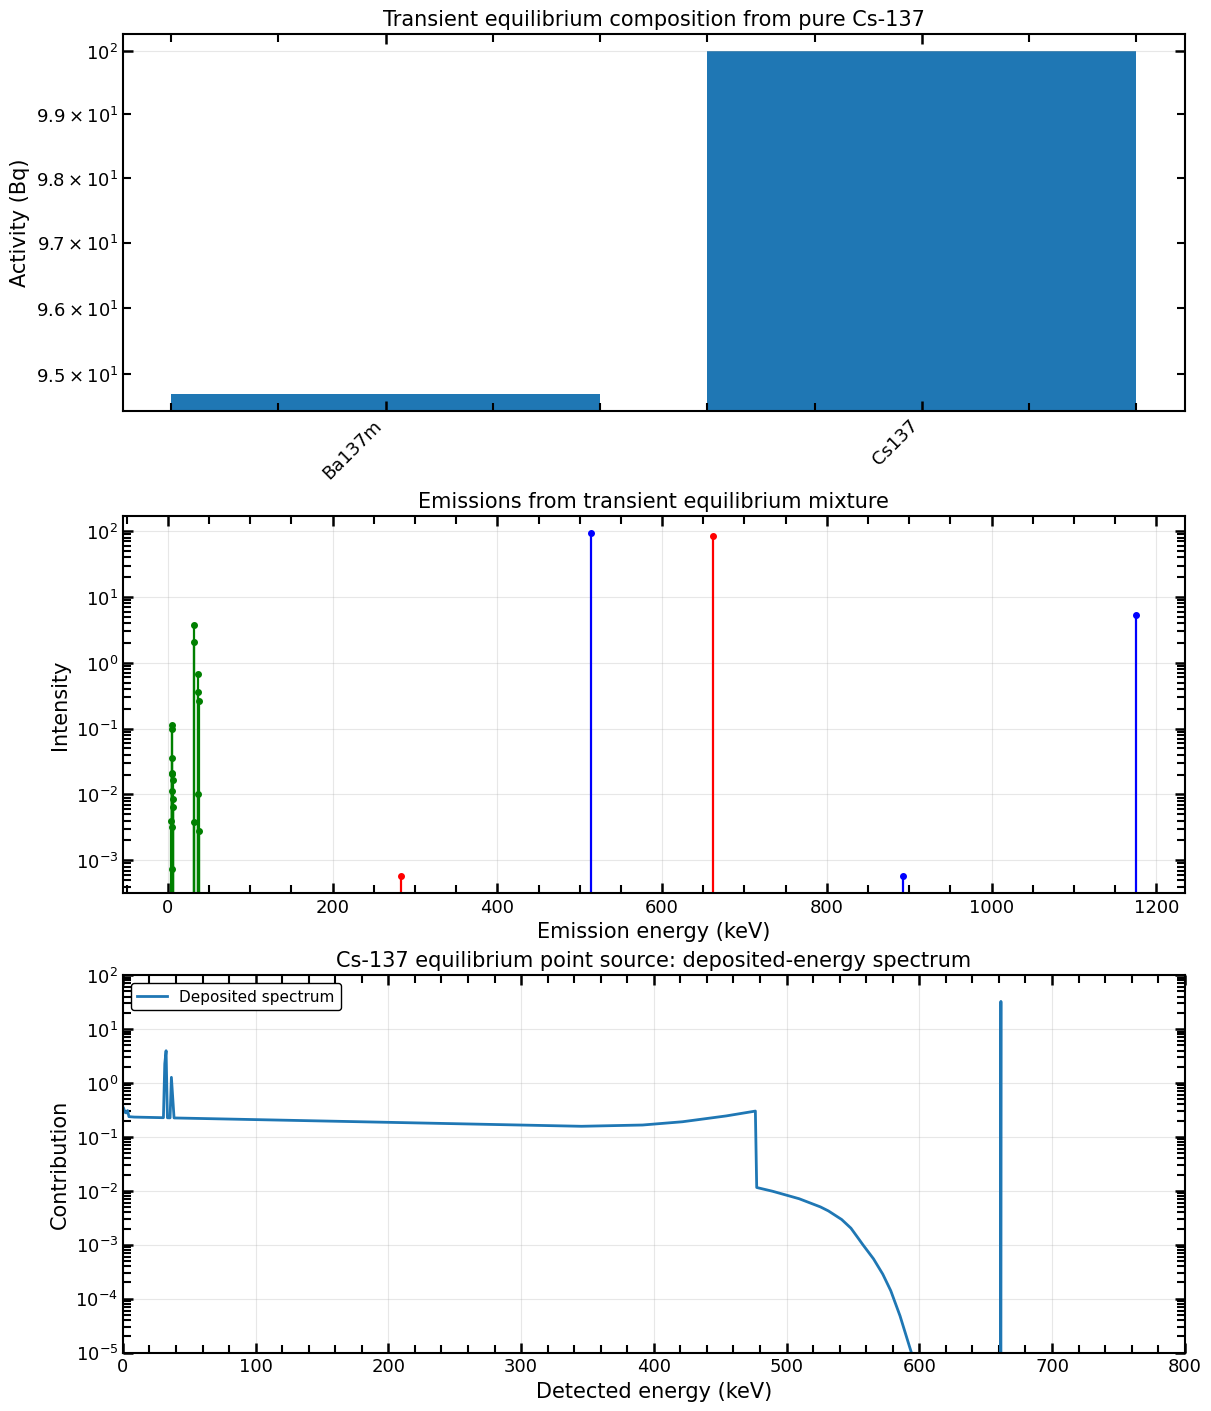

In [9]:
# Plot
plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.labelsize": 15,
        "legend.fontsize": 11,
    }
)

fig, axes = plt.subplots(3, 1, figsize=(12, 14), constrained_layout=True)
ax1, ax2, ax3 = axes

# Panel 1: equilibrium activities
labels = [str(s.getNuclide()) for s in eq_sources]
activities = [float(s.getActivity(Units.get("Bq"))) for s in eq_sources]

x = np.arange(len(labels))
ax1.bar(x, activities)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_yscale("log")
ax1.set_ylabel("Activity (Bq)")
ax1.set_title("Transient equilibrium composition from pure Cs-137")
ax1.grid(True, axis="y", alpha=0.3)

# Panel 2: emission lines
if len(beta_E) > 0:
    beta_plot = ax2.stem(beta_E, beta_I, linefmt="b-", markerfmt="bo", basefmt=" ")
    plt.setp(beta_plot.stemlines, linewidth=1.6)
    plt.setp(beta_plot.markerline, markersize=4)

if len(gamma_E) > 0:
    gamma_plot = ax2.stem(gamma_E, gamma_I, linefmt="r-", markerfmt="ro", basefmt=" ")
    plt.setp(gamma_plot.stemlines, linewidth=1.6)
    plt.setp(gamma_plot.markerline, markersize=4)

if len(xray_E) > 0:
    xray_plot = ax2.stem(xray_E, xray_I, linefmt="g-", markerfmt="go", basefmt=" ")
    plt.setp(xray_plot.stemlines, linewidth=1.6)
    plt.setp(xray_plot.markerline, markersize=4)

ax2.set_xlabel("Emission energy (keV)")
ax2.set_ylabel("Intensity")
ax2.set_yscale("log")
ax2.set_title("Emissions from transient equilibrium mixture")
ax2.grid(True, alpha=0.3)

# Panel 3: deposited spectrum
ax3.plot(E_dep, total_spectrum, linewidth=2, label="Deposited spectrum")
ax3.set_yscale("log")
ax3.set_xlim(0, 800)
ax3.set_ylim(1e-5, 1e2)
ax3.set_xlabel("Detected energy (keV)")
ax3.set_ylabel("Contribution")
ax3.set_title("Cs-137 equilibrium point source: deposited-energy spectrum")
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.show()


In [10]:
# Numerical summary
print("\nPhoton-line deposition summary:")
for item in line_summaries:
    print(
        f"E = {item['energy']:9.3f} keV | "
        f"I = {item['intensity']:.6e} | "
        f"I_eff = {item['scaled_intensity']:.6e} | "
        f"photo = {item['photo']:.6e} | "
        f"pair = {item['pair']:.6e} | "
        f"single = {item['single_escape']:.6e} | "
        f"double = {item['double_escape']:.6e} | "
        f"continuum sum = {item['continuum_sum']:.6e} | "
        f"total sum = {item['total_sum']:.6e}"
    )

print(f"\nTotal deposited spectrum sum: {total_spectrum.sum():.6e}")



Photon-line deposition summary:
E =   283.500 keV | I = 5.800000e-04 | I_eff = 5.800000e-04 | photo = 4.092951e-04 | pair = 0.000000e+00 | single = 0.000000e+00 | double = 0.000000e+00 | continuum sum = 4.925340e-04 | total sum = 9.018291e-04
E =   661.657 keV | I = 8.513481e+01 | I_eff = 8.513481e+01 | photo = 3.255034e+01 | pair = 0.000000e+00 | single = 0.000000e+00 | double = 0.000000e+00 | continuum sum = 9.159365e+01 | total sum = 1.241440e+02
E =    31.452 keV | I = 3.877925e-03 | I_eff = 3.877925e-03 | photo = 3.820110e-03 | pair = 0.000000e+00 | single = 0.000000e+00 | double = 0.000000e+00 | continuum sum = 1.767930e-04 | total sum = 3.996903e-03
E =    31.817 keV | I = 2.054435e+00 | I_eff = 2.054435e+00 | photo = 2.030801e+00 | pair = 0.000000e+00 | single = 0.000000e+00 | double = 0.000000e+00 | continuum sum = 8.895814e-02 | total sum = 2.119759e+00
E =    32.194 keV | I = 3.784077e+00 | I_eff = 3.784077e+00 | photo = 3.737737e+00 | pair = 0.000000e+00 | single = 0.00000